In [19]:
# Install all required Python libraries
# Computer Vision
!pip -q install opencv-python

# Data Processing
!pip -q install pandas numpy

# Visualization
!pip -q install matplotlib seaborn

# Image Processing
!pip -q install pillow

# Progress Bar
!pip -q install tqdm
print("✅ All libraries installed successfully.")

✅ All libraries installed successfully.


In [ ]:
# Mount Google Drive
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

print("\nGoogle Drive Mounted Successfully!")

Mounted at /content/drive

Google Drive Mounted Successfully!


In [ ]:
# Import all required libraries
# ============================================================

import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd

from tqdm import tqdm

from PIL import Image

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Display settings
plt.rcParams["figure.figsize"] = (8,6)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
print(os.listdir("/content/drive/MyDrive/RxHandBD-ML"))

['Test_Label.csv', 'Train_Label.csv', 'Test_Set', 'Train_Set']


In [7]:
print("Train Images :", len(os.listdir("/content/drive/MyDrive/RxHandBD-ML/Train_Set")))
print("Test Images :", len(os.listdir("/content/drive/MyDrive/RxHandBD-ML/Test_Set")))

Train Images : 535
Test Images : 1115


In [8]:
# ============================================================
# CELL 5.5
# Verify Dataset Consistency
# ============================================================

import os
import pandas as pd

train_df = pd.read_csv(Train_Label.csv)
test_df = pd.read_csv(Test_label.csv)

print("="*60)
print("DATASET CONSISTENCY CHECK")
print("="*60)

print(f"Images in Train Folder : {len(os.listdir(TRAIN_DIR))}")
print(f"Rows in Train CSV      : {len(train_df)}")

print()

print(f"Images in Test Folder  : {len(os.listdir(TEST_DIR))}")
print(f"Rows in Test CSV       : {len(test_df)}")

print("\nTrain CSV Columns :", train_df.columns.tolist())
print("Test CSV Columns  :", test_df.columns.tolist())

print("\nFirst Five Training Samples")
display(train_df.head())

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/RxHandBD/Train_Label.csv'

In [9]:
print("ROOT_DIR :", ROOT_DIR)
print("TRAIN_CSV:", TRAIN_CSV)
print("TEST_CSV :", TEST_CSV)

ROOT_DIR : /content/drive/MyDrive/RxHandBD
TRAIN_CSV: /content/drive/MyDrive/RxHandBD/Train_Label.csv
TEST_CSV : /content/drive/MyDrive/RxHandBD/Test_Label.csv


In [10]:
import os

ROOT_DIR = "/content/drive/MyDrive/RxHandBD-ML"

TRAIN_DIR = os.path.join(ROOT_DIR, "Train_Set")
TEST_DIR = os.path.join(ROOT_DIR, "Test_Set")

TRAIN_CSV = os.path.join(ROOT_DIR, "Train_Label.csv")
TEST_CSV = os.path.join(ROOT_DIR, "Test_Label.csv")

print(ROOT_DIR)
print(TRAIN_CSV)
print(TEST_CSV)

/content/drive/MyDrive/RxHandBD-ML
/content/drive/MyDrive/RxHandBD-ML/Train_Label.csv
/content/drive/MyDrive/RxHandBD-ML/Test_Label.csv


In [11]:
import os

print(os.path.exists(TRAIN_CSV))
print(os.path.exists(TEST_CSV))

True
True


In [12]:
import pandas as pd

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print(train_df.head())

      Images         Text
0  P1116.jpg       Dexter
1  P1117.jpg  Clavusef sw
2  P1118.jpg   m-lucas 10
3  P1119.jpg    Dophyllin
4  P1120.jpg      Delfian


In [14]:
# ============================================================
# CELL 7
# Dataset Information
# ============================================================

print("="*60)
print("TRAIN DATASET INFORMATION")
print("="*60)

train_df.info()

print()

print("="*60)
print("TEST DATASET INFORMATION")
print("="*60)

test_df.info()

TRAIN DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4463 entries, 0 to 4462
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Images  4463 non-null   object
 1   Text    4463 non-null   object
dtypes: object(2)
memory usage: 69.9+ KB

TEST DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Images  1115 non-null   object
 1   Text    1115 non-null   object
dtypes: object(2)
memory usage: 17.6+ KB


In [15]:
# ============================================================
# CELL 8
# Check Missing Values and Duplicates
# ============================================================

print("="*60)
print("TRAIN DATASET")
print("="*60)

print("\nMissing Values")
display(train_df.isnull().sum())

print("\nDuplicate Rows :", train_df.duplicated().sum())

print()

print("="*60)
print("TEST DATASET")
print("="*60)

print("\nMissing Values")
display(test_df.isnull().sum())

print("\nDuplicate Rows :", test_df.duplicated().sum())

TRAIN DATASET

Missing Values


,0
Images,0
Text,0



Duplicate Rows : 0

TEST DATASET

Missing Values


,0
Images,0
Text,0



Duplicate Rows : 0


In [21]:
# ============================================================
# CELL 8.5
# Import Required Libraries (if runtime restarted)
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


In [24]:
# ============================================================
# Find Missing Images in Training Set
# ============================================================

missing_train = []

for img in train_df["Images"]:
    img = img.strip()  # remove accidental spaces

    if not os.path.exists(os.path.join(TRAIN_DIR, img)):
        missing_train.append(img)

print("="*60)
print("Missing Training Images")
print("="*60)

print("Total Missing :", len(missing_train))

print("\nFirst 20 Missing Files:")
print(missing_train[:20])

Missing Training Images
Total Missing : 3928

First 20 Missing Files:
['P1651.jpg', 'P1652.jpg', 'P1653.jpg', 'P1654.jpg', 'P1655.jpg', 'P1656.jpg', 'P1657.jpg', 'P1658.jpg', 'P1659.jpg', 'P1660.jpg', 'P1661.jpg', 'P1662.jpg', 'P1663.jpg', 'P1664.jpg', 'P1665.jpg', 'P1666.jpg', 'P1667.jpg', 'P1668.jpg', 'P1669.jpg', 'P1670.jpg']


In [25]:
# ============================================================
# Find Missing Images in Test Set
# ============================================================

missing_test = []

for img in test_df["Images"]:
    img = img.strip()

    if not os.path.exists(os.path.join(TEST_DIR, img)):
        missing_test.append(img)

print("="*60)
print("Missing Test Images")
print("="*60)

print("Total Missing :", len(missing_test))

print("\nFirst 20 Missing Files:")
print(missing_test[:20])

Missing Test Images
Total Missing : 0

First 20 Missing Files:
[]


In [26]:
print("Train Folder Images :", len(os.listdir(TRAIN_DIR)))
print("Train CSV Rows      :", len(train_df))

print()

print("Test Folder Images  :", len(os.listdir(TEST_DIR)))
print("Test CSV Rows       :", len(test_df))

Train Folder Images : 535
Train CSV Rows      : 4463

Test Folder Images  : 1115
Test CSV Rows       : 1115


In [27]:
train_files = sorted(os.listdir(TRAIN_DIR))

print("First 20:")
print(train_files[:20])

print("\nLast 20:")
print(train_files[-20:])

First 20:
['P1116.jpg', 'P1117.jpg', 'P1118.jpg', 'P1119.jpg', 'P1120.jpg', 'P1121.jpg', 'P1122.jpg', 'P1123.jpg', 'P1124.jpg', 'P1125.jpg', 'P1126.jpg', 'P1127.jpg', 'P1128.jpg', 'P1129.jpg', 'P1130.jpg', 'P1131.jpg', 'P1132.jpg', 'P1133.jpg', 'P1134.jpg', 'P1135.jpg']

Last 20:
['P1631.jpg', 'P1632.jpg', 'P1633.jpg', 'P1634.jpg', 'P1635.jpg', 'P1636.jpg', 'P1637.jpg', 'P1638.jpg', 'P1639.jpg', 'P1640.jpg', 'P1641.jpg', 'P1642.jpg', 'P1643.jpg', 'P1644.jpg', 'P1645.jpg', 'P1646.jpg', 'P1647.jpg', 'P1648.jpg', 'P1649.jpg', 'P1650.jpg']


In [28]:
# ============================================================
# CELL 15
# Keep Only Existing Images
# ============================================================

print("="*60)
print("FILTERING TRAIN DATASET")
print("="*60)

# Remove accidental spaces
train_df["Images"] = train_df["Images"].str.strip()

# Keep only rows whose image exists
train_df = train_df[
    train_df["Images"].apply(
        lambda x: os.path.isfile(os.path.join(TRAIN_DIR, x))
    )
].reset_index(drop=True)

print("Remaining Training Samples :", len(train_df))

display(train_df.head())

FILTERING TRAIN DATASET
Remaining Training Samples : 535


,Images,Text
0,P1116.jpg,Dexter
1,P1117.jpg,Clavusef sw
2,P1118.jpg,m-lucas 10
3,P1119.jpg,Dophyllin
4,P1120.jpg,Delfian


In [29]:
# ============================================================
# CELL 16
# Verify Filtered Dataset
# ============================================================

missing = []

for img in train_df["Images"]:

    path = os.path.join(TRAIN_DIR, img)

    if not os.path.exists(path):
        missing.append(img)

print("="*60)

print("Missing Images :", len(missing))

print("="*60)

assert len(missing) == 0

print("✅ All training images are available.")

Missing Images : 0
✅ All training images are available.


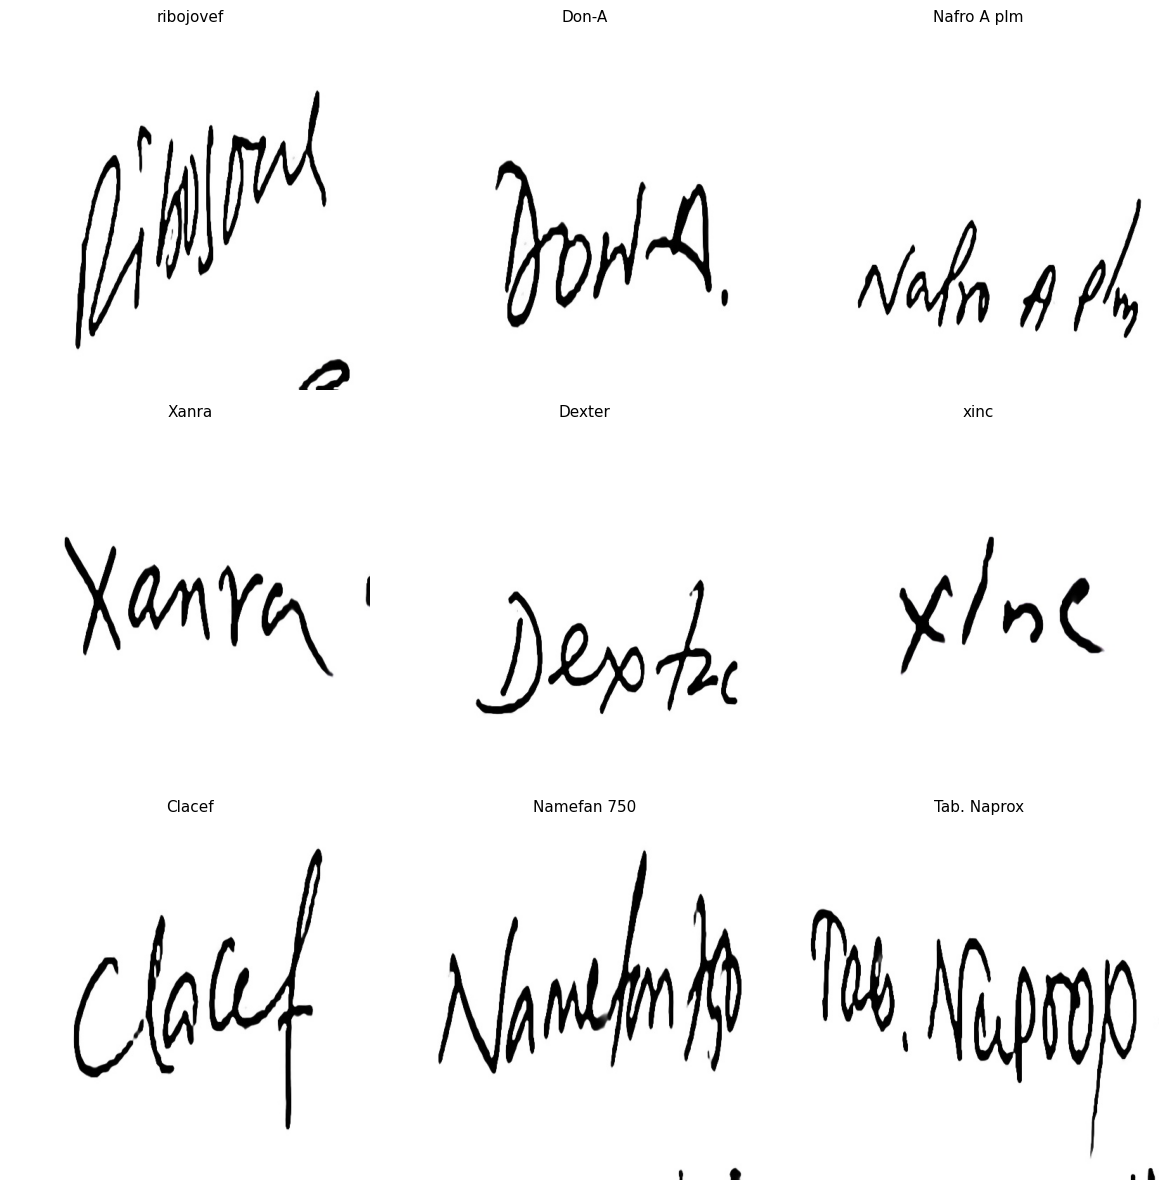

In [30]:
# ============================================================
# CELL 17
# Visualize Random Samples
# ============================================================

import random
import cv2
import matplotlib.pyplot as plt

samples = train_df.sample(9, random_state=42)

plt.figure(figsize=(12,12))

for i, (_, row) in enumerate(samples.iterrows()):

    path = os.path.join(TRAIN_DIR, row["Images"])

    img = cv2.imread(path)

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(row["Text"], fontsize=11)
    plt.axis("off")

plt.tight_layout()

plt.show()

In [31]:
# ============================================================
# CELL 18
# Create Output Directories
# ============================================================

OUTPUT_DIR = os.path.join(ROOT_DIR, "Processed")

TRAIN_OUTPUT = os.path.join(OUTPUT_DIR, "Train")

TEST_OUTPUT = os.path.join(OUTPUT_DIR, "Test")

os.makedirs(TRAIN_OUTPUT, exist_ok=True)
os.makedirs(TEST_OUTPUT, exist_ok=True)

print("Output folders created successfully.")

Output folders created successfully.


In [32]:
# ============================================================
# CELL 19
# Image Preprocessing
# ============================================================

import numpy as np
import cv2

def preprocess_image(path):

    image = cv2.imread(path)

    if image is None:
        return None

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    gray = clahe.apply(gray)

    gray = cv2.medianBlur(gray,3)

    _, thresh = cv2.threshold(
        gray,
        240,
        255,
        cv2.THRESH_BINARY_INV
    )
    coords = cv2.findNonZero(thresh)

    if coords is not None:

        x, y, w, h = cv2.boundingRect(coords)

        gray = gray[y:y+h, x:x+w]

    h, w = gray.shape

    scale = 224 / max(h,w)
    nh = int(h*scale)

    nw = int(w*scale)
    resized = cv2.resize(gray,(nw,nh))

    canvas = np.ones((224,224),dtype=np.uint8)*255

    yoff = (224-nh)//2
    xoff = (224-nw)//2
    canvas[yoff:yoff+nh,xoff:xoff+nw] = resized

    return canvas

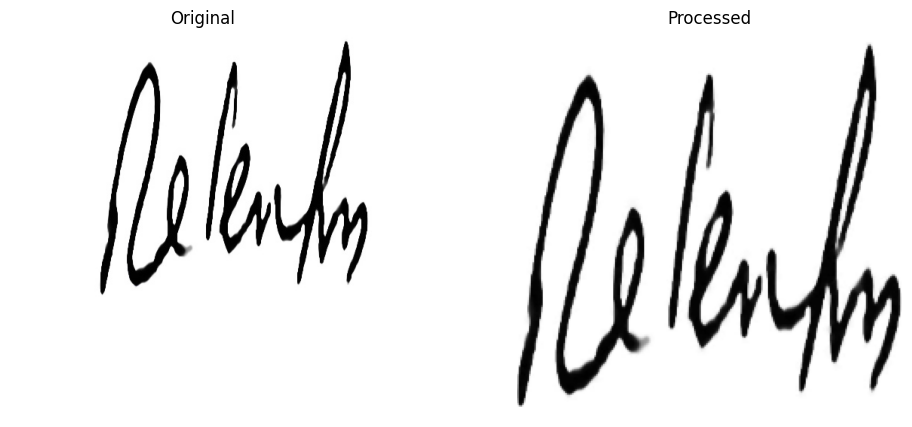

In [33]:
# ============================================================
# CELL 20
# Before vs After
# ============================================================

sample = train_df.sample(1).iloc[0]

path = os.path.join(TRAIN_DIR, sample["Images"])

original = cv2.imread(path)
original = cv2.cvtColor(original,cv2.COLOR_BGR2RGB)

processed = preprocess_image(path)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(processed,cmap="gray")
plt.title("Processed")
plt.axis("off")

plt.show()